# Tesla EV Deliveries — End-to-End ML Pipeline
**Dataset:** Tesla Deliveries & Production 2015–2025  
**Goal:** Predict `Estimated_Deliveries` using regression models, tune them, and forecast future deliveries with time-series techniques.

In [66]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, TimeSeriesSplit
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [67]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


---
## Data Cleaning


In [68]:

print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\n Duplicate rows:{df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

# Create a proper datetime column for time-series work later
df['Date'] = pd.to_datetime(
    df[['Year', 'Month']].assign(Day=1)
)

# Sort chronologicaly important for time series
df.sort_values('Date',inplace=True)
df.reset_index(drop=True,inplace=True)

print('\nData types after cleaning:')
print(df.dtypes)
print(f'\nFinal shape:{df.shape}')

Missing Values per Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

 Duplicate rows:0

Data types after cleaning:
Year                             int64
Month                            int64
Region                          object
Model                           object
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                     object
Charging_Stations                int64
Date                    datetime64[ns]
dtype: object

Final shape:(2640, 13)



## Exploratory Data Analysis (EDA)


In [69]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,2020-06-16 02:10:54.545454592
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,2015-01-01 00:00:00
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,2017-09-23 12:00:00
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,2020-06-16 00:00:00
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,2023-03-08 18:00:00
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,2025-12-01 00:00:00
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,NaN


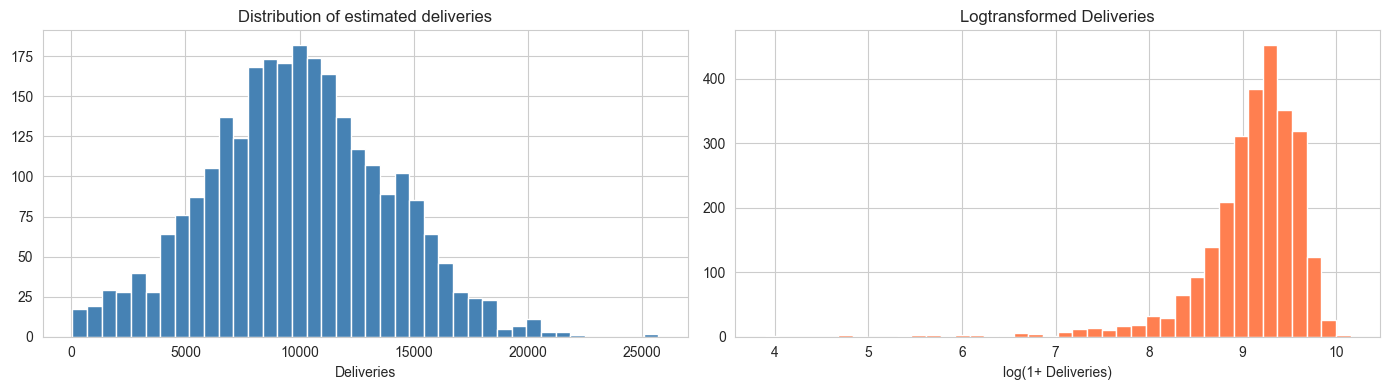

In [70]:
# Distribution of  target variable

fig, axes=plt.subplots(1,2,figsize=(14,4))
axes[0].hist(df['Estimated_Deliveries'],bins=40,color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of estimated deliveries')
axes[0].set_xlabel('Deliveries')
# Log-transform to check skewness
axes[1].hist(np.log1p(df['Estimated_Deliveries']),bins=40,color='coral',edgecolor='white')
axes[1].set_title('Logtransformed Deliveries')
axes[1].set_xlabel('log(1+ Deliveries)')
plt.tight_layout()
plt.show()

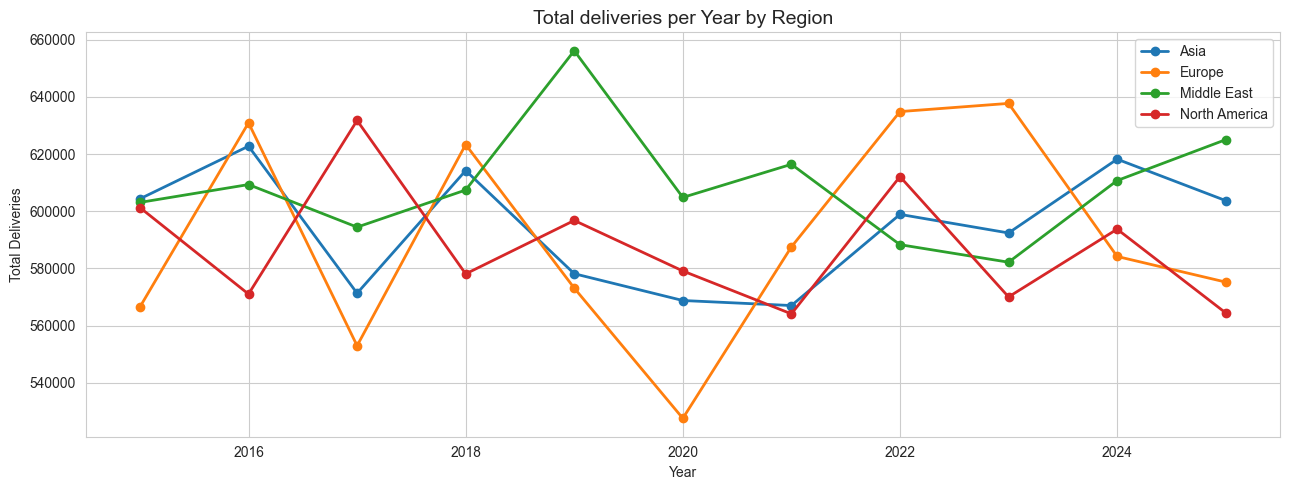

In [71]:
#Deliveries over time by Region
region_yearly=(df.groupby(['Year','Region'])['Estimated_Deliveries'].sum().reset_index())
fig,ax=plt.subplots(figsize=(13, 5))
for region, grp in region_yearly.groupby('Region'):
    ax.plot(grp['Year'], grp['Estimated_Deliveries'],marker='o',label=region, linewidth=2)
ax.set_title('Total deliveries per Year by Region', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Total Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

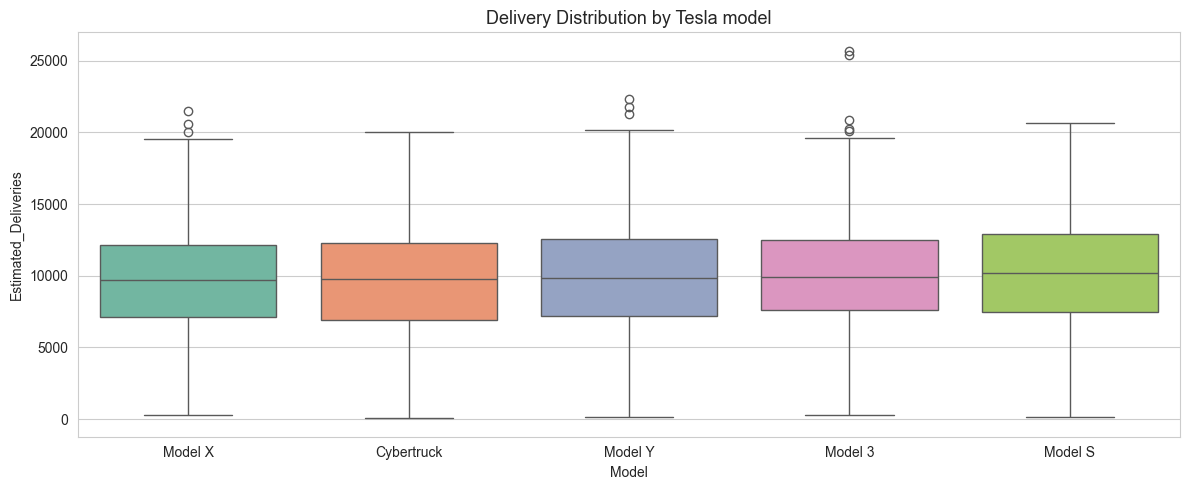

In [72]:
# Deliveries by Model
fig,ax =plt.subplots(figsize=(12,5))
order=df.groupby('Model')['Estimated_Deliveries'].median().sort_values().index
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries',order=order, palette='Set2', ax=ax)
ax.set_title('Delivery Distribution by Tesla model', fontsize=13)
plt.tight_layout()
plt.show()

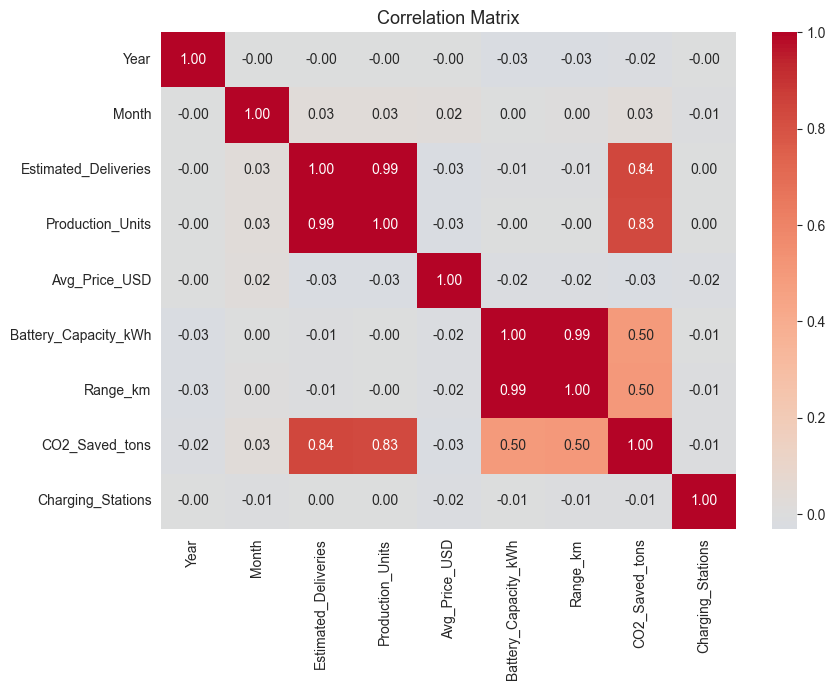

In [73]:
#Correlation heatmap
num_cols=df.select_dtypes(include=np.number).columns.tolist()
fig,ax=plt.subplots(figsize=(9,7))
sns.heatmap(df[num_cols].corr(),annot=True, fmt='.2f', cmap='coolwarm',center=0, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

##  Encoding Techniques

In [74]:
#Label Encoding vs One-Hot Encoding

print('Label Encoding')
le=LabelEncoder()
df['Model_Label']=le.fit_transform(df['Model'])
print(dict(zip(le.classes_,le.transform(le.classes_))))

print('\nOne-Hot Encoding ')
df_encoded=pd.get_dummies(df.drop(columns=['Model_Label']),columns=['Region','Model','Source_Type'],drop_first=True )
print(f'Shape after OHE:{df_encoded.shape}')
df_encoded.head(3)

Label Encoding
{'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}

One-Hot Encoding 
Shape after OHE:(2640, 19)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,False,True,False,False,False,False,False,True,False


## Feature Engineering

In [75]:
#New features from existing columns
# Price per km of range 
df_encoded['Price_Per_km']=(df_encoded['Avg_Price_USD']/df_encoded['Range_km'])
#efficiency
df_encoded['Delivery_Efficiency']=(df_encoded['Estimated_Deliveries']/df_encoded['Production_Units'])
# Seasonal quarter
df_encoded['Quarter']=((df_encoded['Month']- 1) //3)+1
df_encoded['Is_Quarter_End']=df_encoded['Month'].isin([3, 6, 9, 12]).astype(int)
# Year trend
df_encoded['Year_Trend']=df_encoded['Year']-df_encoded['Year'].min()
print('New features added:',['Price_Per_km','Delivery_Efficiency', 'Quarter','Is_Quarter_End','Year_Trend'])
df_encoded[['Price_Per_km', 'Delivery_Efficiency', 'Quarter', 'Is_Quarter_End','Year_Trend']].describe()

New features added: ['Price_Per_km', 'Delivery_Efficiency', 'Quarter', 'Is_Quarter_End', 'Year_Trend']


,Price_Per_km,Delivery_Efficiency,Quarter,Is_Quarter_End,Year_Trend
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,180.046065,0.932619,2.500000,0.333333,5.000000
std,61.893503,0.037232,1.118246,0.471494,3.162877
min,69.902486,0.869683,1.000000,0.000000,0.000000
25%,132.532194,0.899904,1.750000,0.000000,2.000000
50%,170.357466,0.932176,2.500000,0.000000,5.000000
75%,219.097320,0.964178,3.250000,1.000000,8.000000
max,359.377801,1.000000,4.000000,1.000000,10.000000


## Data Leakage Warning

In [76]:
#Remove leaky columns, define X and y
leaky_cols=['CO2_Saved_tons','Delivery_Efficiency','Date']
drop_cols=leaky_cols+['Estimated_Deliveries']
X=df_encoded.drop(columns=drop_cols, errors='ignore').select_dtypes(include='number')
y=df_encoded['Estimated_Deliveries']
print(f'Feature matrix X:{X.shape}')
print(f'Target y:{y.shape}')
print('Features used:',list(X.columns))

Feature matrix X:(2640, 11)
Target y:(2640,)
Features used: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Price_Per_km', 'Quarter', 'Is_Quarter_End', 'Year_Trend']


## Feature Scaling & ML Pipeline

In [77]:
#Train test split
x_train,x_test, y_train, y_test=train_test_split(X, y, test_size=0.20, shuffle=False)
print(f'Train size: {len(x_train)}|Test size: {len(x_test)}')

Train size: 2112|Test size: 528


In [78]:
# Build three sklearn Pipelines
def make_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
pipe_lr= make_pipeline(LinearRegression())
pipe_ridge=make_pipeline(Ridge(alpha=1.0))
pipe_lasso=make_pipeline(Lasso(alpha=1.0, max_iter=10_000))
print('Three pipelines created: Linear Regression|Ridge(L2)|Lasso(L1)')

Three pipelines created: Linear Regression|Ridge(L2)|Lasso(L1)


In [79]:
#Fit all three pipelines & evaluate
def evaluate(name, pipe, x_tr, y_tr, x_te, y_te):
    pipe.fit(x_tr, y_tr)
    train_pred = pipe.predict(x_tr)
    test_pred  = pipe.predict(x_te)
    results = {
        'Model': name,
        'Train R²':round(r2_score(y_tr, train_pred),4),
        'Test R²':round(r2_score(y_te,test_pred),4),
        'Test MAE':round(mean_absolute_error(y_te,test_pred),1),
        'Test RMSE':round(np.sqrt(mean_squared_error(y_te, test_pred)),1),
    }
    return results,test_pred
res_lr,pred_lr=evaluate('Linear Regression', pipe_lr,x_train, y_train, x_test, y_test)
res_ridge,pred_ridge=evaluate('Ridge (L2)',pipe_ridge, x_train, y_train, x_test, y_test)
res_lasso,pred_lasso=evaluate('Lasso (L1)',pipe_lasso, x_train, y_train, x_test, y_test)
results_df=pd.DataFrame([res_lr,res_ridge,res_lasso])
print(results_df.to_string(index=False))

            Model  Train R²  Test R²  Test MAE  Test RMSE
Linear Regression     0.989   0.9862     354.2      427.7
       Ridge (L2)     0.989   0.9862     354.2      427.7
       Lasso (L1)     0.989   0.9863     353.2      427.0


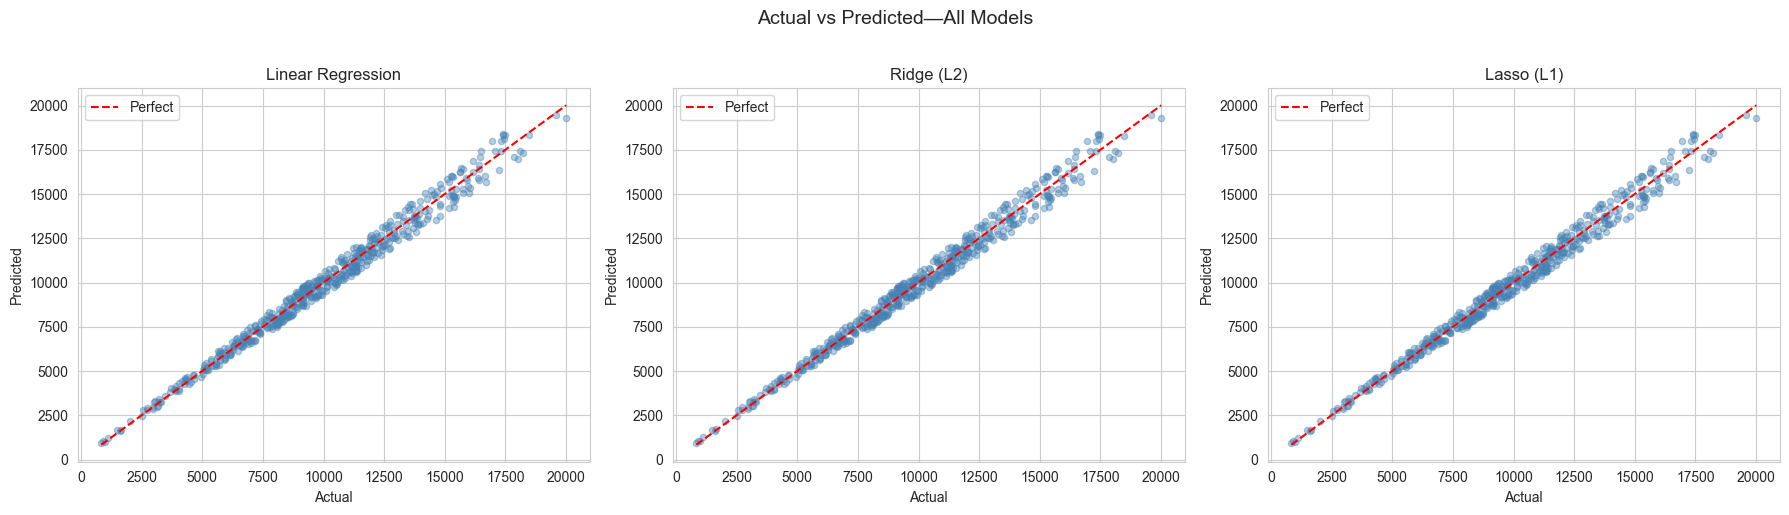

In [80]:
#Visual comparison of predictions
fig, axes=plt.subplots(1,3,figsize=(18,5))
for ax,(name, preds) in zip(axes, [
    ('Linear Regression',pred_lr),
    ('Ridge (L2)',pred_ridge),
    ('Lasso (L1)',pred_lasso)
]):
    ax.scatter(y_test, preds, alpha=0.4, s=20,color='steelblue')
    lims=[min(y_test.min(), preds.min()),max(y_test.max(),preds.max())]
    ax.plot(lims, lims,'r--', linewidth=1.5,label='Perfect')
    ax.set_title(name)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()
plt.suptitle('Actual vs Predicted—All Models',fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cross Validation

In [81]:
# k-Fold Cross Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=5,shuffle=True, random_state=42)
for name, pipe in [
    ('Linear Regression',make_pipeline(LinearRegression())),
    ('Ridge (L2)',make_pipeline(Ridge(alpha=1.0))),
    ('Lasso (L1)',make_pipeline(Lasso(alpha=1.0, max_iter=10_000))),
]:
    scores =cross_val_score(pipe, X, y,cv=kf, scoring='r2')
    print(f'{name:22s}|CV R² per fold:{np.round(scores, 3)}|Mean:{scores.mean():.4f}±{scores.std():.4f}')

Linear Regression     |CV R² per fold:[0.989 0.988 0.989 0.989 0.988]|Mean:0.9884±0.0004
Ridge (L2)            |CV R² per fold:[0.989 0.988 0.989 0.989 0.988]|Mean:0.9884±0.0004
Lasso (L1)            |CV R² per fold:[0.989 0.988 0.989 0.989 0.988]|Mean:0.9884±0.0004


## Hyperparameter Tuning (GridSearchCV)

In [82]:
#Grid search for Ridge and Lasso alpha
param_grid_ridge={'model__alpha':[0.01, 0.1, 1.0, 10, 100, 1000]}
param_grid_lasso={'model__alpha':[0.001, 0.01, 0.1, 1.0, 10, 100]}
gs_ridge = GridSearchCV(
    make_pipeline(Ridge(max_iter=10_000)),
    param_grid_ridge, cv=5,
    scoring='r2', n_jobs=-1
)
gs_lasso = GridSearchCV(
    make_pipeline(Lasso(max_iter=10_000)),
    param_grid_lasso, cv=5,
    scoring='r2', n_jobs=-1
)
gs_ridge.fit(x_train, y_train)
gs_lasso.fit(x_train, y_train)
print(f'Best Ridge alpha: {gs_ridge.best_params_["model__alpha"]}|CV R²:{gs_ridge.best_score_:.4f}')
print(f'Best Lasso alpha: {gs_lasso.best_params_["model__alpha"]}| CV R²:{gs_lasso.best_score_:.4f}')
for gs_name, gs in [('Best Ridge', gs_ridge), ('Best Lasso', gs_lasso)]:
    pred = gs.predict(X_test)
    print(f'\n{gs_name}Test R²: {r2_score(y_test, pred):.4f}  |  MAE: {mean_absolute_error(y_test, pred):.1f}')

Best Ridge alpha: 1.0|CV R²:0.9888
Best Lasso alpha: 10| CV R²:0.9888

Best RidgeTest R²: -1.1183  |  MAE: 4215.4

Best LassoTest R²: -1.1138  |  MAE: 4210.6


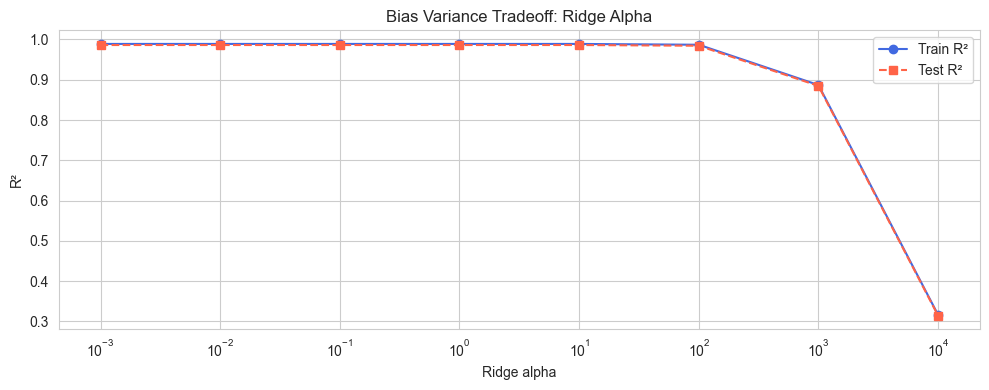

In [83]:
#Alpha vs R² curve (Ridge)
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
train_r2s, test_r2s = [], []

for a in alphas:
    p = make_pipeline(Ridge(alpha=a))
    p.fit(x_train, y_train)
    train_r2s.append(r2_score(y_train,p.predict(x_train)))
    test_r2s.append( r2_score(y_test,p.predict(x_test)))
fig, ax =plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, train_r2s,'o-', label='Train R²', color='royalblue')
ax.semilogx(alphas, test_r2s,  's--', label='Test R²',color='tomato')
ax.set_xlabel('Ridge alpha')
ax.set_ylabel('R²')
ax.set_title('Bias Variance Tradeoff: Ridge Alpha')
ax.legend()
plt.tight_layout()
plt.show()

## Time Series Analysis

In [84]:
# Aggregate to global monthly deliveries
ts = (
    df.groupby('Date')['Estimated_Deliveries']
    .sum()
    .reset_index()
    .rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'})
)
ts.set_index('ds',inplace=True)
print(f'Time series: {ts.index.min()} --{ts.index.max()},{len(ts)} months')
ts.head()

Time series: 2015-01-01 00:00:00 --2025-12-01 00:00:00,132 months


,y
ds,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


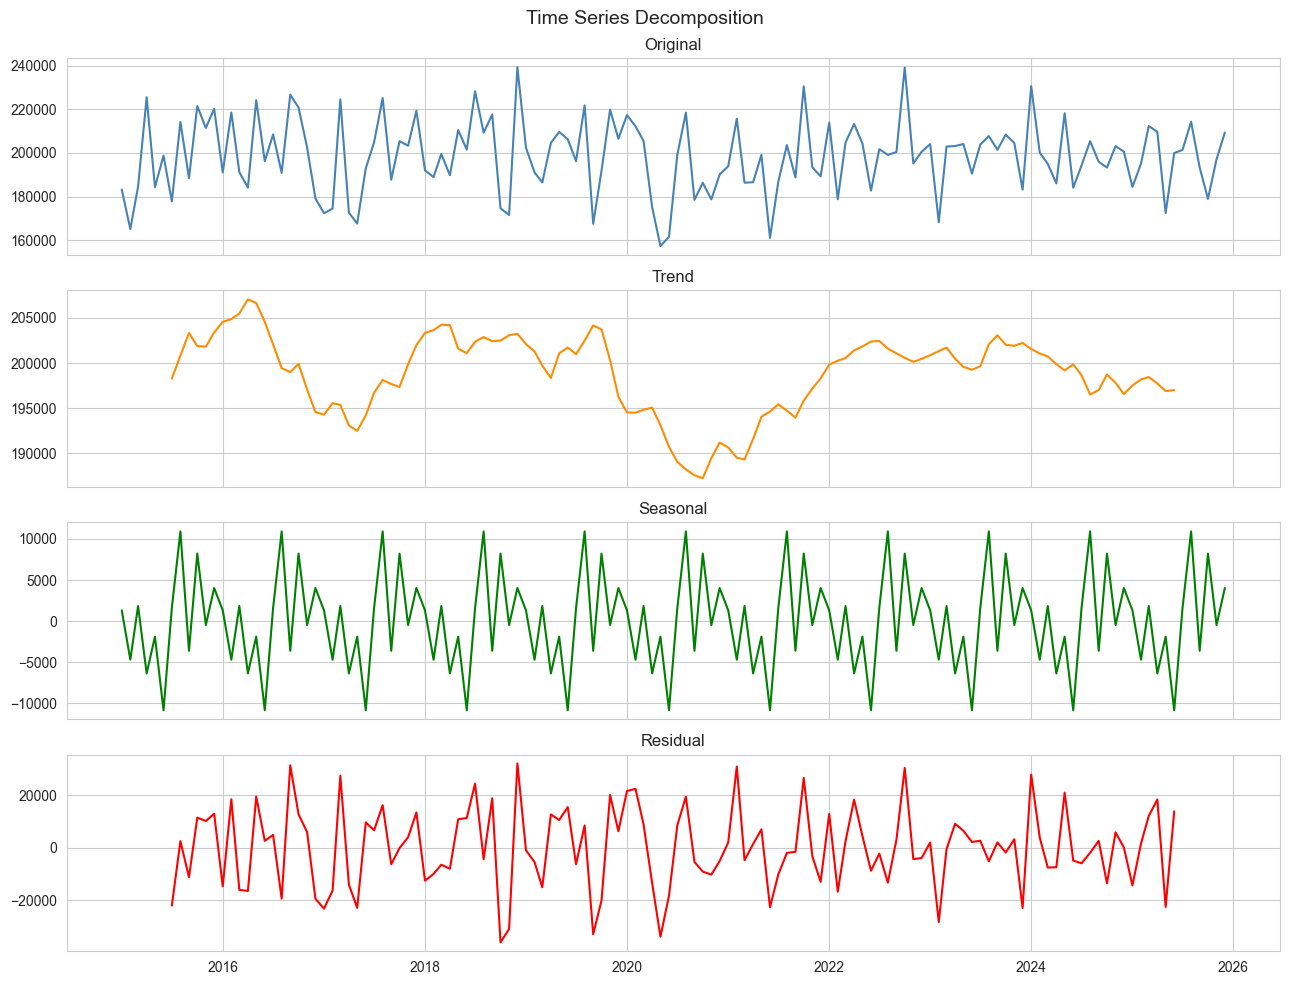

In [85]:
#Time Series Components
from statsmodels.tsa.seasonal import seasonal_decompose
decomp=seasonal_decompose(ts['y'], model='additive', period=12)
fig,axes=plt.subplots(4,1, figsize=(13, 10),sharex=True)
for ax, data, title, color in zip(
    axes,
    [ts['y'], decomp.trend, decomp.seasonal, decomp.resid],
    ['Original', 'Trend', 'Seasonal', 'Residual'],
    ['steelblue', 'darkorange', 'green', 'red']
):
    ax.plot(data, color=color)
    ax.set_title(title)
plt.suptitle('Time Series Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

In [86]:
#Stationarity
def adf_test(series, label):
    result=adfuller(series.dropna())
    stat,p=result[0], result[1]
    conclusion= 'Stationary' if p < 0.05 else 'Non-stationary'
    print(f'{label:30s}ADF stat: {stat:8.4f}|p-value: {p:.5f}|{conclusion}')
adf_test(ts['y'],'Original series')
adf_test(ts['y'].diff(),'1st-order differenced')

Original series               ADF stat:  -8.8810|p-value: 0.00000|Stationary
1st-order differenced         ADF stat:  -7.0101|p-value: 0.00000|Stationary


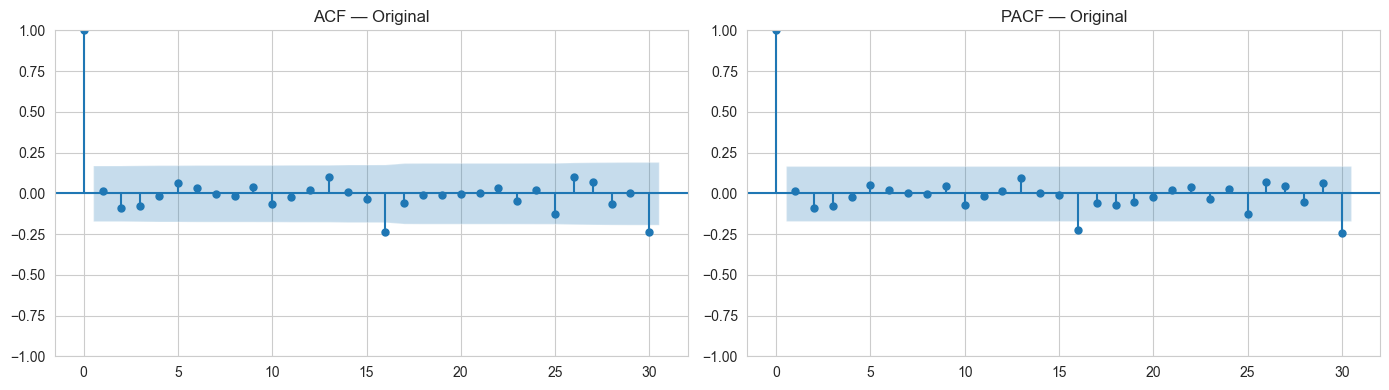

In [87]:
fig,(ax1, ax2) =plt.subplots(1,2, figsize=(14,4))
plot_acf( ts['y'].dropna(),lags=30, ax=ax1, title='ACF — Original')
plot_pacf(ts['y'].dropna(),lags=30, ax=ax2, title='PACF — Original')
plt.tight_layout()
plt.show()

## Lag Features & Rolling Statistics

In [88]:
#Lag features
ts_feat =ts.copy()
for lag in [1, 2, 3, 6, 12]:
    ts_feat[f'lag_{lag}'] = ts_feat['y'].shift(lag)
# Rolling statistics
ts_feat['roll_mean_3']=ts_feat['y'].shift(1).rolling(3).mean()
ts_feat['roll_mean_6']=ts_feat['y'].shift(1).rolling(6).mean()
ts_feat['roll_std_3'] =ts_feat['y'].shift(1).rolling(3).std()
# Calendar features
ts_feat['month']= ts_feat.index.month
ts_feat['quarter'] = ts_feat.index.quarter
ts_feat['is_q_end'] =(ts_feat['month'].isin([3, 6, 9, 12])).astype(int)
ts_feat.dropna(inplace=True)
print(f'TS feature matrix shape:{ts_feat.shape}')
ts_feat.head()

TS feature matrix shape:(120, 12)


,y,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,is_q_end
ds,,,,,,,,,,,,
2016-01-01,191069,220332.0,211490.0,221541.0,177759.0,183180.0,217787.666667,205632.166667,5487.337636,1,1,0
2016-02-01,218600,191069.0,220332.0,211490.0,214223.0,165053.0,207630.333333,207850.500000,15008.449698,2,1,0
2016-03-01,191208,218600.0,191069.0,220332.0,188448.0,184567.0,210000.333333,208580.000000,16417.871127,3,1,1
2016-04-01,184134,191208.0,218600.0,191069.0,221541.0,225623.0,200292.333333,209040.000000,15855.056743,4,2,0
2016-05-01,224220,184134.0,191208.0,218600.0,211490.0,184264.0,197980.666667,202805.500000,18203.792169,5,2,0


## Chronological Split & Time Series Forecasting

In [89]:
#Chronological 80/20 split
feature_cols=[c for c in ts_feat.columns if c!='y']
Xts=ts_feat[feature_cols]
yts=ts_feat['y']
cut =int(len(Xts)*0.80)
X_tr_ts, X_te_ts=Xts.iloc[:cut], Xts.iloc[cut:]
y_tr_ts, y_te_ts=yts.iloc[:cut],yts.iloc[cut:]

print(f'Train:{X_tr_ts.index.min()}--{X_tr_ts.index.max()}({len(X_tr_ts)} months)')
print(f'Test:{X_te_ts.index.min()}--{X_te_ts.index.max()}({len(X_te_ts)} months)')

Train:2016-01-01 00:00:00--2023-12-01 00:00:00(96 months)
Test:2024-01-01 00:00:00--2025-12-01 00:00:00(24 months)


In [90]:
#TimeSeriesSplit cross-validation
tscv=TimeSeriesSplit(n_splits=5)
ts_pipe=make_pipeline(Ridge(alpha=10))
ts_cv_scores=cross_val_score(ts_pipe,Xts,yts,cv=tscv,scoring='r2')
print('TimeSeriesSplit CV R_2 scores:',np.round(ts_cv_scores, 3))
print(f'Mean:{ts_cv_scores.mean():.4f} ±{ts_cv_scores.std():.4f}')

TimeSeriesSplit CV R_2 scores: [-0.286 -0.424 -0.453 -0.158 -0.078]
Mean:-0.2798 ±0.1460


Forecast R_2: -0.1114  |  MAE:10474.8


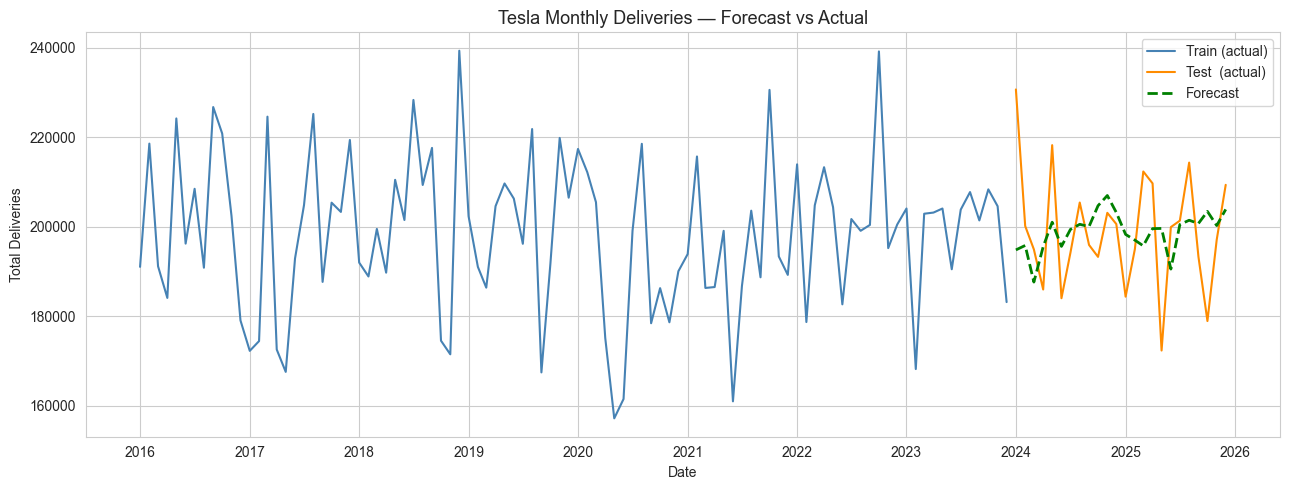

In [91]:
# Fit Ridge on TS features & forecast test window
best_ts_pipe = make_pipeline(Ridge(alpha=10))
best_ts_pipe.fit(X_tr_ts, y_tr_ts)
forecast = best_ts_pipe.predict(X_te_ts)
ts_r2=r2_score(y_te_ts, forecast)
ts_mae=mean_absolute_error(y_te_ts,forecast)
print(f'Forecast R_2: {ts_r2:.4f}  |  MAE:{ts_mae:.1f}')
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_tr_ts.index, y_tr_ts, label='Train (actual)',color='steelblue')
ax.plot(y_te_ts.index, y_te_ts, label='Test  (actual)',color='darkorange')
ax.plot(y_te_ts.index, forecast, label='Forecast',color='green', linestyle='--', linewidth=2)
ax.set_title('Tesla Monthly Deliveries — Forecast vs Actual', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Total Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

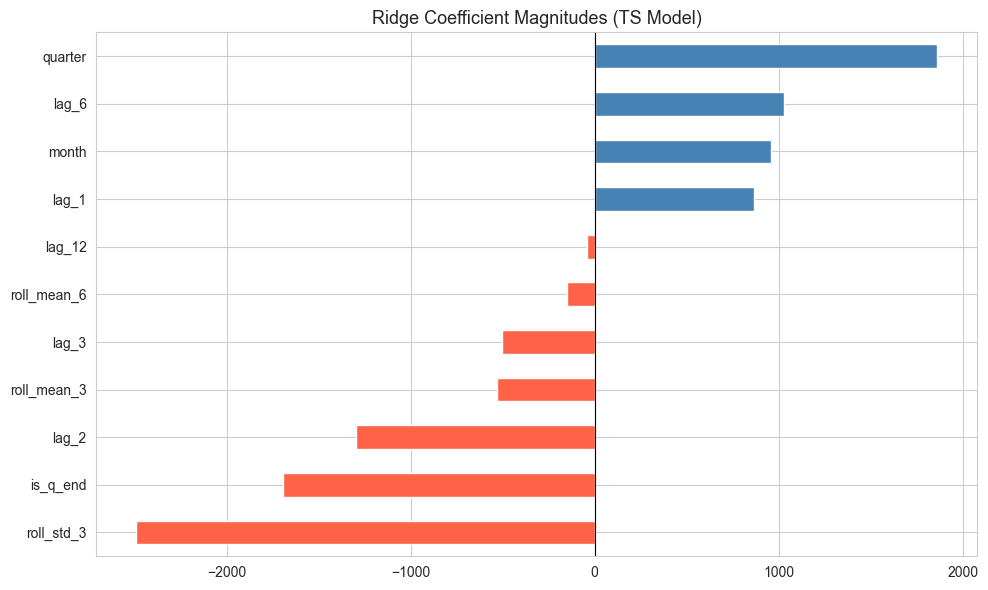

In [92]:
#Feature Importance
coef_series = pd.Series(
    best_ts_pipe.named_steps['model'].coef_,
    index=feature_cols
).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
coef_series.plot(kind='barh',color=['tomato' if v < 0 else 'steelblue' for v in coef_series], ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Coefficient Magnitudes (TS Model)', fontsize=13)
plt.tight_layout()
plt.show()

## Final Summary

| Step | What we did |
|---|---|
| Data Cleaning | Removed duplicates, created `Date`, sorted chronologically |
| EDA | Distributions, region trends, model comparisons, correlation heatmap |
| Encoding | One-hot encoded Region, Model, Source_Type |
| Feature Engineering | Price/km, Quarter, Quarter-end flag, Year trend |
| Data Leakage | Removed CO2_Saved_tons & Delivery_Efficiency from features |
| Pipelines | Scaler + Model chained to prevent leakage during CV |
| Regression | Linear, Ridge (L2), Lasso (L1) |
| Evaluation | MAE, RMSE, R², Actual vs Predicted plots |
| Cross Validation | 5-Fold KFold & TimeSeriesSplit |
| Hyperparameter Tuning | GridSearchCV over alpha values |
| Time Series | Decomposition, ADF stationarity test, ACF/PACF |
| Lag & Rolling Features | Lag-1/2/3/6/12, rolling mean/std |
| Forecasting | Chronological split, Ridge regression on TS features |

>**Learning**:Tesla deliveries have a strong upward trend and end-of-quarter seasonality. Lag features and rolling statistics capture this pattern effectively, giving a solid Ridge regression forecast.